## 
Plots 
Alaska extRemes analysis on TXx

'Loc & scale: time':  location.fun= ~ glost, scale.fun = ~glost <br>

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
import geopandas as gpd

import matplotlib.colors as mcolors


In [3]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [4]:
import warnings
warnings.filterwarnings('ignore')

# READ EVGAM output FILES

In [ ]:
yearb=1941
yeare=2025
lon_min = 235
lon_max = 293
lat_min = 25
lat_max = 50

dirin =''

dsj = xr.open_dataset('era5_Summer_snowd_mask.nc')

ds0 = xr.open_dataset(f'{dirin}/TXx_Alaska_ij_LocScaglost_extremes_1941_2025.nc')
dsj = dsj.sel(lon=ds0['lon'],lat=ds0['lat'])
maskSd = dsj['maskSd']
ds0=ds0.where(maskSd==1)
rl1000 = ds0['rl100']
loc0 = ds0['location'] 
scale0 = ds0['scale'] 
shape0 = ds0['shape'] 
LocationDiff_q0 = ds0['LocationDiff_q']
ScaleDiff_q0 = ds0['ScaleDiff_q']
RLDiff_q0 = ds0['RLDiff_q']
RiskRatios_q0 = ds0['RiskRatios_q']
CRPS0 = ds0['CRPS']
DawSeb0 = ds0['DawSeb']
SE0 = ds0['SE']
KS_D0 = ds0['KS_D']
KS_pvalue0 = ds0['KS_pvalue']
CVM_D0 = ds0['CVM_D']
CVM_pvalue0 = ds0['CVM_pvalue']

units = '°F'

Tlabels = ['Loc & scale: glost']


# Scores & tests

In [6]:
proj=ccrs.PlateCarree()

In [7]:
from matplotlib import cm
## Build colorbar
clevsa=np.arange(0.06,1.01,0.01)
clevsb=np.arange(0,0.051,0.001)
pvalue_clevs=np.concatenate((clevsb,clevsa))
cmap = cm.get_cmap('Purples',len(clevsa)+20)
cmaplist = [cmap(i) for i in range(20,cmap.N)]
cmap2 = cm.get_cmap('YlGn_r', len(clevsb)+5)
cmaplist2 = [cmap2(i) for i in range(0,cmap2.N-5)]

pvalue_cmap = colors.LinearSegmentedColormap.from_list('Custom cmap',\
                cmaplist2+cmaplist, len(cmaplist2)+len(cmaplist))

##########
##########

Text(0.5, 0.98, 'Test statistic - p.value')

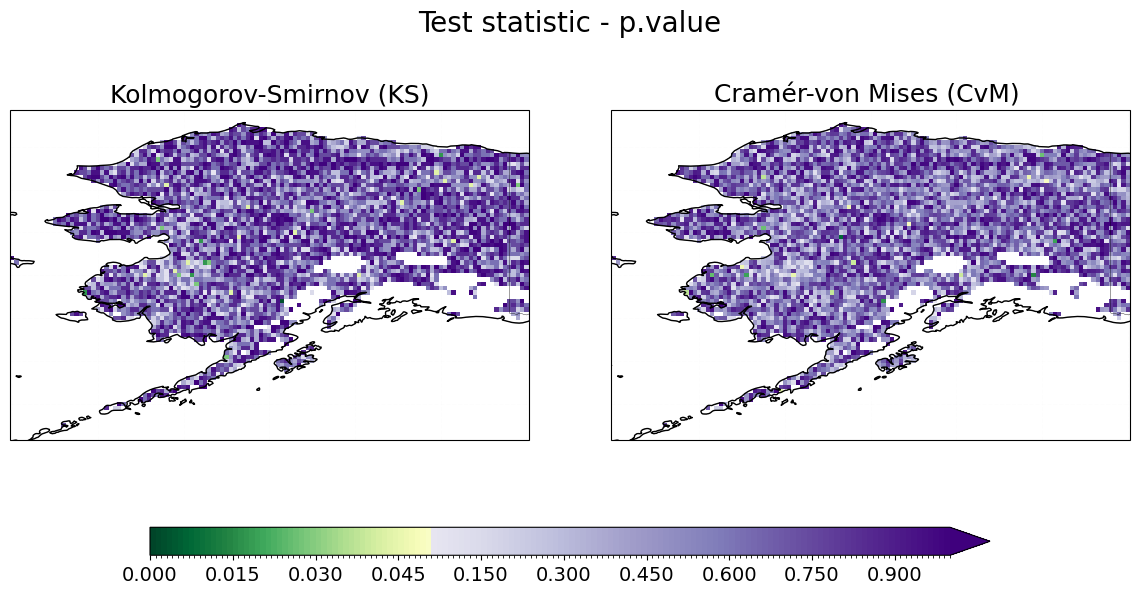

In [17]:
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.04,wspace=0.16)
ax = ax.flatten()
cc = KS_pvalue0.plot.pcolormesh(ax=ax[0],cmap=pvalue_cmap,levels=pvalue_clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[0].set_title(f'Kolmogorov-Smirnov (KS)',fontsize=18)  
cc = CVM_pvalue0.plot.pcolormesh(ax=ax[1],cmap=pvalue_cmap,levels=pvalue_clevs,transform=ccrs.PlateCarree(),add_colorbar=False)
ax[1].set_title(f'Cramér-von Mises (CvM) ',fontsize=18)  

for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label='',fontsize=16)
#

plt.suptitle(f'Test statistic - p.value',fontsize=20)  

Text(0.5, 0.98, 'Tests averaged in Time')

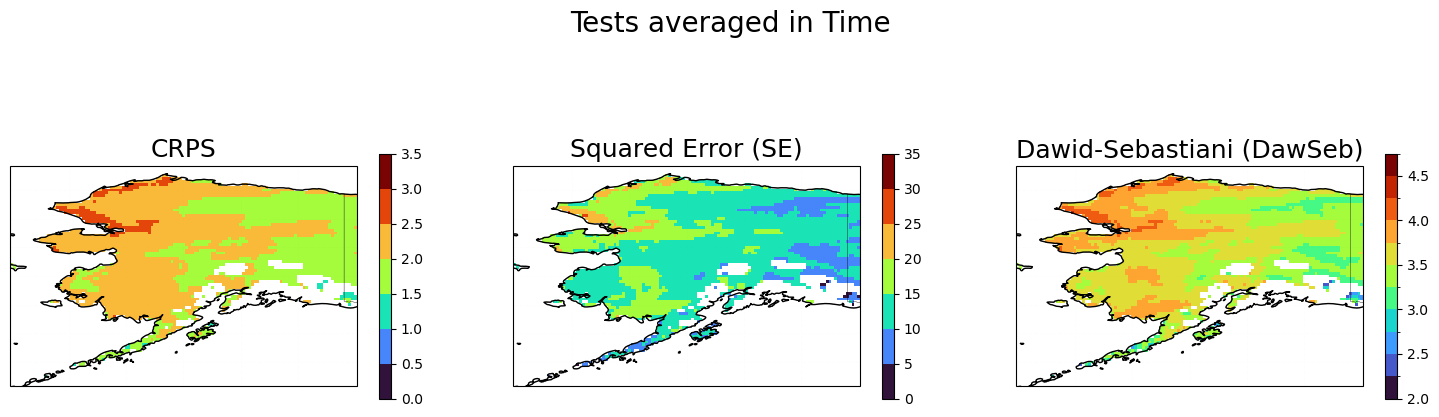

In [21]:
proj=ccrs.PlateCarree()


fig, ax = plt.subplots(nrows=1,ncols=3,figsize=(18,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.95,hspace=0.04,wspace=0.16)
ax = ax.flatten()
clevs = np.arange(0,4,0.5)
cc = CRPS0.mean('time').plot.pcolormesh(ax=ax[0],cmap='turbo',levels=clevs,transform=ccrs.PlateCarree(),cbar_kwargs={'shrink':0.5,'label':''})
ax[0].set_title(f'CRPS',fontsize=18)  
clevs = np.arange(0,40,5)
cc = SE0.mean('time').plot.pcolormesh(ax=ax[1],cmap='turbo',levels=clevs,transform=ccrs.PlateCarree(),cbar_kwargs={'shrink':0.5,'label':''})
ax[1].set_title(f'Squared Error (SE)',fontsize=18)  
clevs = np.arange(2,5,0.25)
cc = DawSeb0.mean('time').plot.pcolormesh(ax=ax[2],cmap='turbo',levels=clevs,transform=ccrs.PlateCarree(),cbar_kwargs={'shrink':0.5,'label':''})
ax[2].set_title(f'Dawid-Sebastiani (DawSeb)',fontsize=18)  

for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  grd.top_labels = False   # Disable top labels
  grd.right_labels = False # Disable right labels. 
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15)
  ax[ix].coastlines()

#

plt.suptitle(f'Tests averaged in Time',fontsize=20)  

In [24]:
vq=[0.95,0.05]
proj=ccrs.PlateCarree()
Tquantile=['0.95','0.05']

Text(0.5, 0.98, 'Difference 2025-1941 Location parameter')

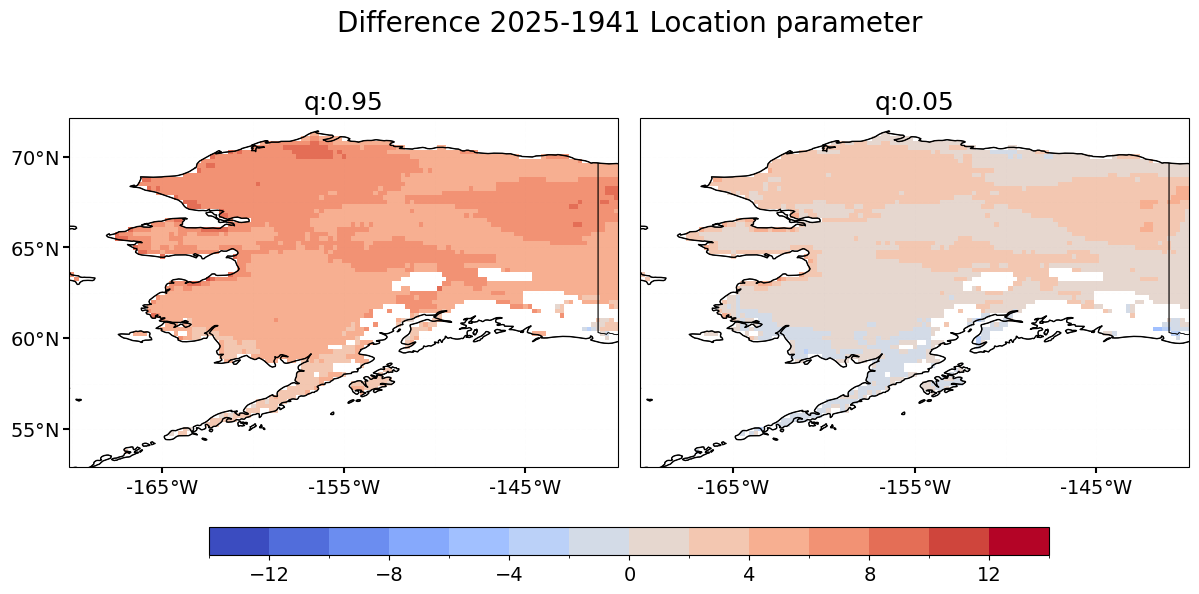

In [33]:
clevs = np.arange(-14,16,2)
cmap = 'coolwarm'

fig, ax = plt.subplots(nrows=1,ncols=len(Tquantile),figsize=(14,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.25,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  cc = LocationDiff_q0.sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
for ix in range(0,len(ax),2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)

plt.suptitle(f'Difference {yeare}-{yearb} Location parameter',fontsize=20)  

Changes in the GEV location parameter over the period 1941-2025 (2025 parameter values substract 1941 values) and approcimate 90% confidence interval limits.

Text(0.5, 0.98, 'Difference 2025-1941 Scale parameter')

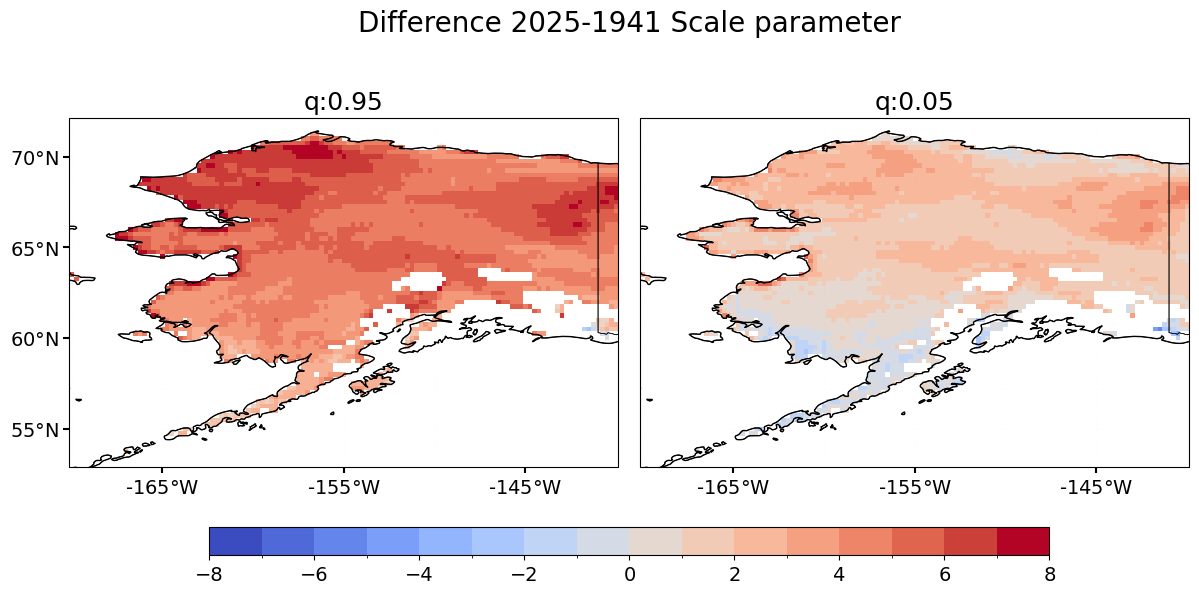

In [34]:
clevs = np.arange(-8,9,1)
cmap = 'coolwarm'

fig, ax = plt.subplots(nrows=1,ncols=len(Tquantile),figsize=(14,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.25,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  cc = LocationDiff_q0.sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
for ix in range(0,len(ax),2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'',fontsize=16)


plt.suptitle(f'Difference {yeare}-{yearb} Scale parameter',fontsize=20)  

Changes in the GEV scale parameter over the period 1941-2025 (2025 parameter values substract 1941 values) and approximate 90% confidence interval limits.

Text(0.5, 0.98, 'Difference 2025-1941 Return Level 100 year')

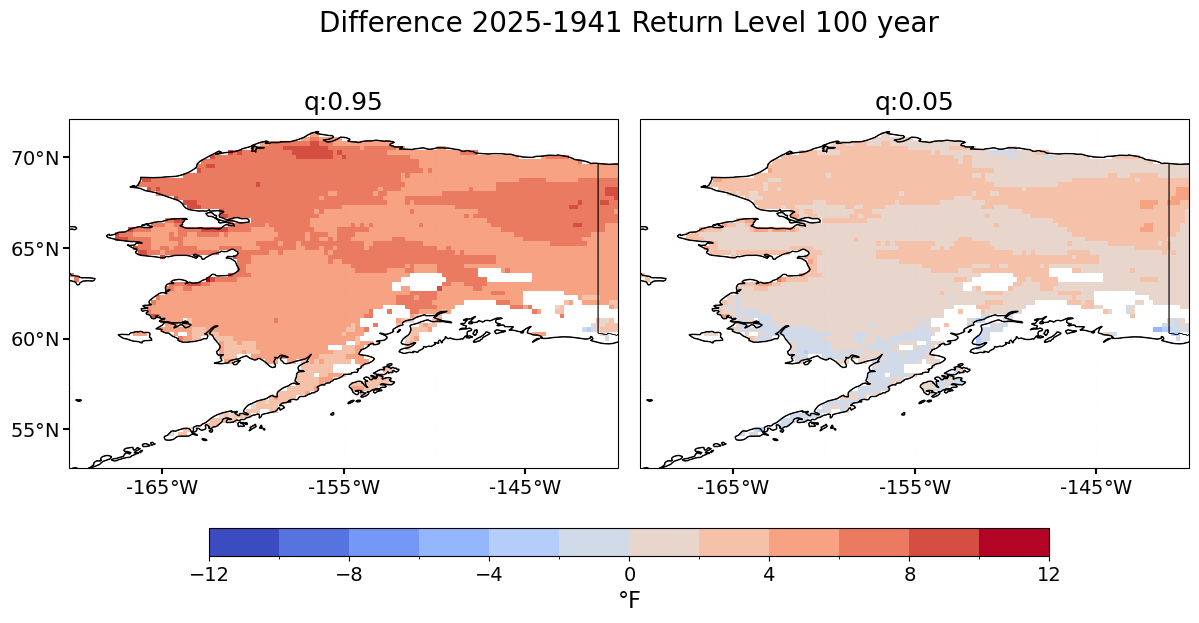

In [37]:
clevs = np.arange(-12,14,2)

cmap = 'coolwarm'

fig, ax = plt.subplots(nrows=1,ncols=len(Tquantile),figsize=(14,7),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.25,wspace=0.04)
ax = ax.flatten()
for ix in range(0,len(Tquantile)):
  cc = RLDiff_q0.sel(quantile=vq[ix]).plot.pcolormesh(ax=ax[ix],levels=clevs,cmap=cmap,add_colorbar=False)
  ax[ix].set_title(f'q:{Tquantile[ix]}',fontsize=18)   
##
for ix in range(0,len(ax)):
    ####
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()
  if ix >=len(ax)-2:
    ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
    ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
for ix in range(0,len(ax),2): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal')
cbar.ax.tick_params(labelsize=14)  
cbar.set_label(label=f'{units}',fontsize=16)

plt.suptitle(f'Difference {yeare}-{yearb} Return Level 100 year',fontsize=20)  

The difference (degree F) in the 100-year return levels based on 2025 and 1941 climates (2025 return level substract 1941 return level) and approximate 90% confidence interval limits.

# PLOT Return Level 100

Text(0.5, 0.98, 'Return Level 100year')

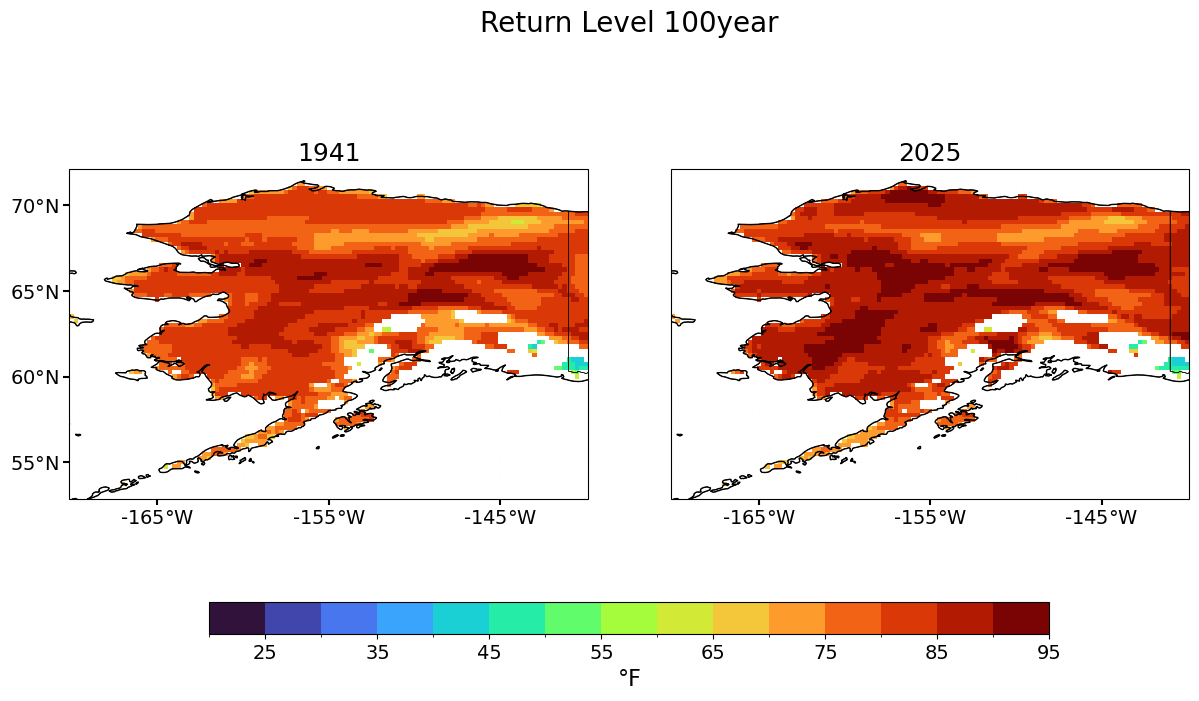

In [62]:
clevs = np.arange(20,100,5)
cmap = plt.get_cmap('turbo',len(clevs)-1).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = rl1000.sel(time=yearb).plot.pcolormesh(ax=ax[0],cmap=cmap,levels=clevs,add_colorbar=False)
ax[0].set_title(yearb,fontsize=18)    
rl1000.sel(time=yeare).plot.pcolormesh(ax=ax[1],cmap=cmap,levels=clevs,add_colorbar=False)
ax[1].set_title(yeare,fontsize=18)    

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[1::2])
cbar.set_label(label=units,fontsize=16)
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Return Level 100year',fontsize=20)  

Text(0.5, 0.98, 'Return Level 100year, Difference 2025 - 1941')

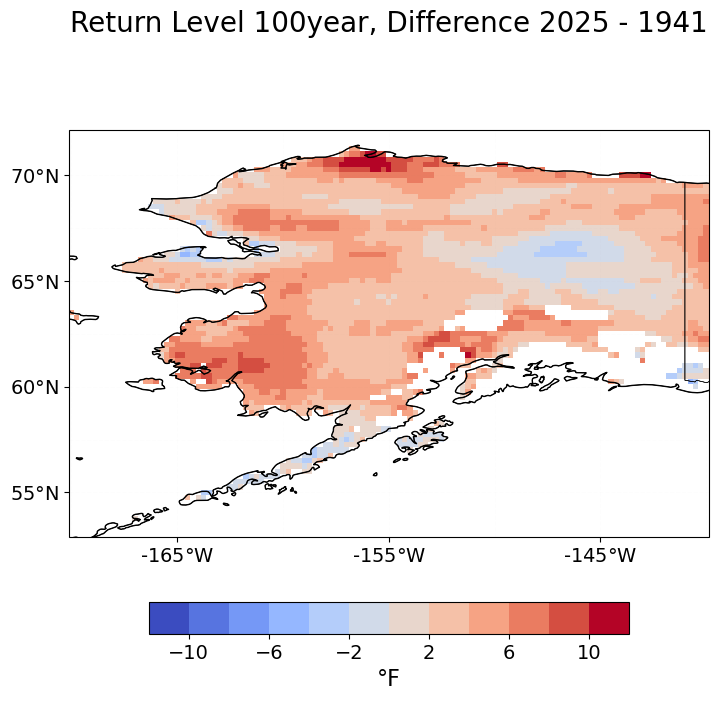

In [54]:
clevs = np.arange(-12,14,2)
cmap = plt.get_cmap('coolwarm',len(clevs)-1).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = (rl1000.sel(time=yeare)-rl1000.sel(time=yearb)).plot.pcolormesh(ax=ax,cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)

####
grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')

ax.set_xlabel('')
ax.set_ylabel('')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
ax.coastlines()
ax.set_xticks(ax.get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax.get_xticks()],size=14)
ax.set_title(f'',fontsize=18)    
ax.set_yticks(ax.get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=14)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[1::2])
cbar.set_label(label=units,fontsize=16)
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Return Level 100year, Difference {yeare} - {yearb}',fontsize=20)  

Text(0.5, 0.98, 'Location parameter')

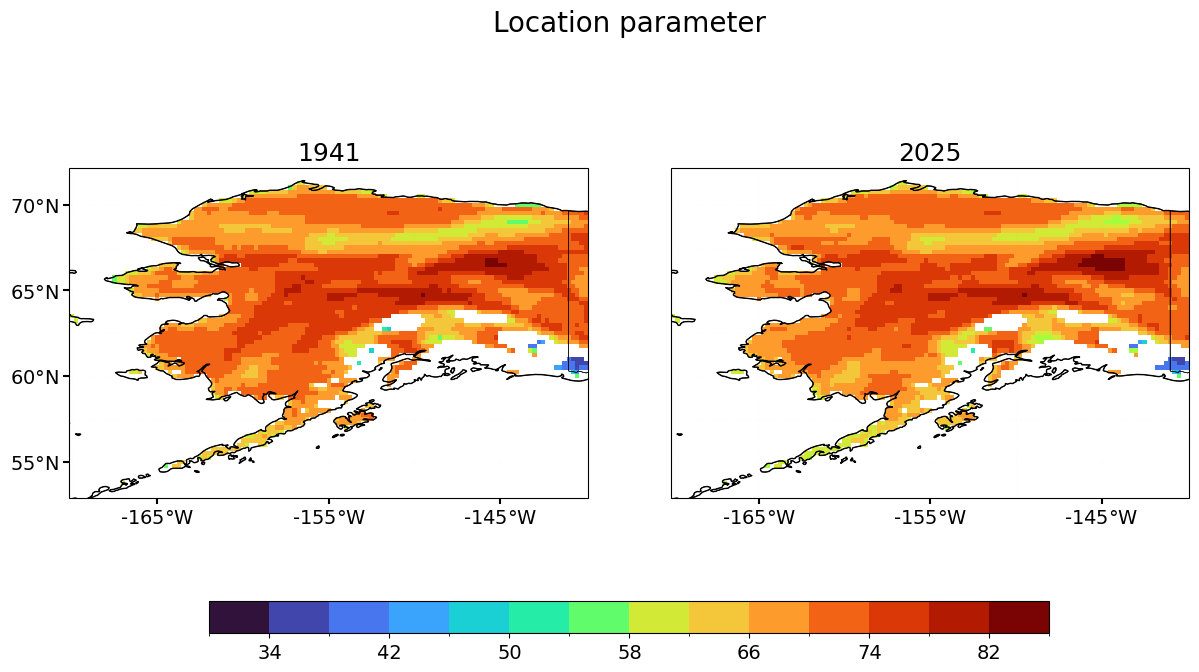

In [67]:
clevs = np.arange(30,88,4)
cmap = plt.get_cmap('turbo',len(clevs)).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = loc0.sel(time=yearb).plot.pcolormesh(ax=ax[0],cmap=cmap,levels=clevs,add_colorbar=False)
ax[0].set_title(yearb,fontsize=18)    
loc0.sel(time=yeare).plot.pcolormesh(ax=ax[1],cmap=cmap,levels=clevs,add_colorbar=False)
ax[1].set_title(yeare,fontsize=18)    

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[1::2])
cbar.set_label(label='',fontsize=16)
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Location parameter',fontsize=20)  

Text(0.5, 0.98, 'Scale parameter')

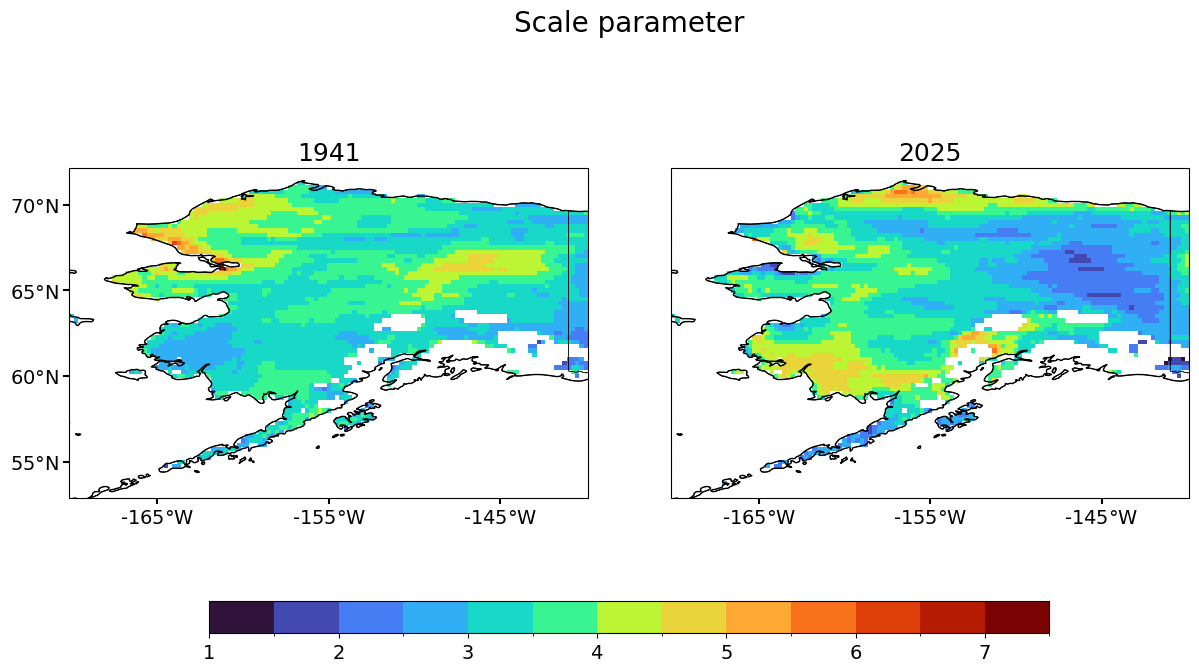

In [74]:
clevs = np.arange(1,8,0.5)
cmap = plt.get_cmap('turbo',len(clevs)).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = scale0.sel(time=yearb).plot.pcolormesh(ax=ax[0],cmap=cmap,levels=clevs,add_colorbar=False)
ax[0].set_title(yearb,fontsize=18)    
scale0.sel(time=yeare).plot.pcolormesh(ax=ax[1],cmap=cmap,levels=clevs,add_colorbar=False)
ax[1].set_title(yeare,fontsize=18)    

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[::2])
cbar.set_label(label='',fontsize=16)
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Scale parameter',fontsize=20)  

Text(0.5, 0.98, 'Shape parameter')

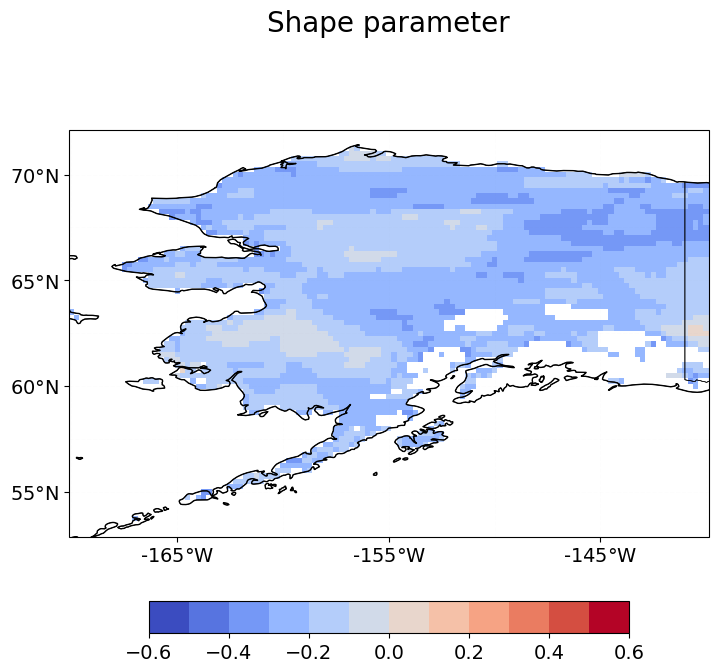

In [55]:
clevs = np.arange(-0.6,0.7,0.1)
cmap = plt.get_cmap('coolwarm',len(clevs)-1).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = shape0.sel(time=yeare).plot.pcolormesh(ax=ax,cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)

####
grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')

ax.set_xlabel('')
ax.set_ylabel('')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
ax.coastlines()
ax.set_xticks(ax.get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax.get_xticks()],size=14)
ax.set_title(f'',fontsize=18)    
ax.set_yticks(ax.get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=14)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[::2])
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Shape parameter',fontsize=20)  